# model training small dataset STL-10
- traditional
    > feature exraction
    - SIFT/HOG
    > model
    - Knn
    - SVM
    - decision Tree
- DL
    - ResNet18

### Step 1 - import all the lib

In [31]:
# training lib

# extraction lib

#
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2 as cv
from sklearn.model_selection import train_test_split
# KNN classifier
from sklearn.neighbors import KNeighborsClassifier
# DT classifier
from sklearn.tree import DecisionTreeClassifier
# SGD classifier
from sklearn.linear_model import SGDClassifier
# comprision display
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    classification_report,
    )
from download import read_all_images, read_labels


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

### Step 2 - define path

In [32]:
from pathlib import Path
import os
result_dir = Path("result")
# model_dir = result_dir / "model"
# analysis_dir = result_dir / "analysis"
# result/svmmodel1/model, result
#data_set_dir = Path("/data_set")
img_dir = Path("img")


### Step 3 Fetch data

In [33]:
# fetch training znd valid data how to do this

# we dont need to use the split do we?
# Extract 300 for each type

# after extract show the image
train_images = read_all_images(
    "./data/stl10_binary/train_X.bin"
)
train_labels = read_labels(
    "./data/stl10_binary/train_y.bin"
)

test_images = read_all_images(
    "./data/stl10_binary/test_X.bin"
)
test_labels = read_labels(
    "./data/stl10_binary/test_y.bin"
)

print(train_images.shape)  # (5000, 96, 96, 3)
print(train_labels.shape)  # (5000,)

print(test_images.shape)   # (8000, 96, 96, 3)
print(test_labels.shape)   # (8000,)



(5000, 96, 96, 3)
(5000,)
(8000, 96, 96, 3)
(8000,)


- Display and extract 5 classes, 300 for trainingm 100 and 100 for val and test

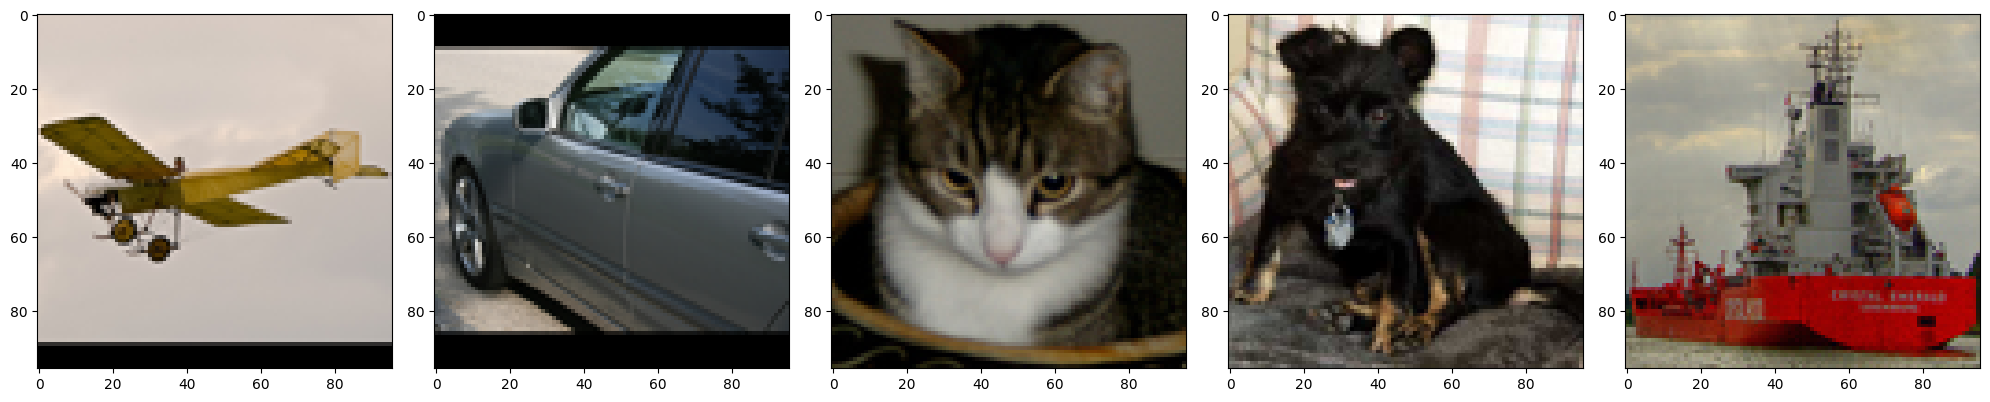

In [46]:
fig, axes = plt.subplots(1, 5, figsize=(20, 7))
axes = axes.ravel()
# select label
#airplane car cat dog ship
selected_label = [1, 3, 4, 6, 9]

mask = np.isin(train_labels, selected_label)
selected_train_X = train_images[mask]
selected_train_y = train_labels[mask]

mask = np.isin(test_labels, selected_label)
selected_test_X = test_images[mask]
selected_test_y = test_labels[mask]

selected_train_indices = []
selected_val_indices = []
selected_test_indices = []

i = 0
rng = np.random.default_rng(42)
for n in selected_label:

    idx = np.where(selected_train_y == n)[0]
    idx = rng.permutation(idx)

    train_idx = idx[:300]
    val_idx = idx[300:400]

    selected_train_indices.extend(train_idx)
    selected_val_indices.extend(val_idx)

    test_idx = np.where(selected_test_y == n)[0]
    test_idx = rng.permutation(test_idx)[:100]
    selected_test_indices.extend(test_idx)
    # idx = np.where(selected_train_y == n)[0]# retun nparray
    # idx = rng.permutation(idx)
    # # get 300 for training
    # train_idx = idx[:300]
    # val_idx = idx[300:400]
    # chosen = np.random.choice(idx, size=300, replace=False)# replace off means same value wont be chose many times

    axes[i].imshow(selected_train_X[train_idx[0]])
    # axes[i].axis("off")
    # selected_train_indices.extend(chosen)
    # # get 100 for val
    # chosen = np.random.choice(idx, size=100, replace=False)# replace off means same value wont be chose many times
    # selected_val_indices.extend(chosen)# append then [s1. s2, s3] //// extend [s1 s2 s3 ]

    # # fet 100 for test
    # idx = np.where(selected_test_y == n)[0]
    # chosen = np.random.choice(idx, size=100, replace=False)# replace off means same value wont be chose many times
    # selected_test_indices.extend(chosen)# append then [s1. s2, s3] //// extend [s1 s2 s3 ]
    i = i + 1


plt.tight_layout()
plt.show()

selected_train_indices = np.array(selected_train_indices)
selected_val_indices = np.array(selected_val_indices)
selected_test_indices = np.array(selected_test_indices)

# selected_label = [1, 3, 4, 6, 9]

train_X = selected_train_X[selected_train_indices]
train_y = selected_train_y[selected_train_indices]

val_X = selected_train_X[selected_val_indices]
val_y = selected_train_y[selected_val_indices]

test_X = selected_test_X[selected_test_indices]
test_y = selected_test_y[selected_test_indices]

# # change label to 0-4
# for label in train_y, val_y, test_y:
    # it is changing temp var
#     result = []
#     for i in label:
#         if i == 1:
#             result.append(0)
#         elif i == 3:
#             result.append(1)
#         elif i == 4:
#             result.append(2)
#         elif i == 6:
#             result.append(3)
#         else:
#             result.append(4)
#     label = np.array(result)
#     print(label.shape)

- label mapping

In [35]:
label_mapping = {
    1: 0,
    3: 1,
    4: 2,
    6: 3,
    9: 4
}

def remap(labels):
    return np.array(
        [label_mapping[int(label)] for label in labels],
        # why int64?
        dtype=np.int64
    )
# print(type(train_y[0]))
train_y = remap(train_y)
# print(type(train_y[0]))
test_y = remap(test_y)
val_y = remap(val_y)
    # it is changing temp var
print(np.unique(train_y, return_counts=True))

(array([0, 1, 2, 3, 4]), array([300, 300, 300, 300, 300]))


- ImageNet standard normalization

In [36]:
from torchvision import transforms

train_transform = transforms.Compose([

    transforms.ToPILImage(),#
    transforms.Resize((224, 224)),#
    transforms.RandomHorizontalFlip(),#
    transforms.RandomRotation(10),#
    transforms.ToTensor(),#
    transforms.Normalize(#
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    )
])

val_test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


- class def

In [37]:
from torch.utils.data import Dataset
import torch
class STL10Subset(Dataset):
    # constrcutor??
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        image = self.images[index]
        label = self.labels[index]

        if self.transform is not None:
            image = self.transform(image)

        label = torch.tensor(
            label,
            dtype=torch.long,
        )

        return image, label

train_dataset = STL10Subset(
    train_X,
    train_y,
    transform=train_transform,
)

val_dataset = STL10Subset(
    val_X,
    val_y,
    transform=val_test_transform,
)

test_dataset = STL10Subset(
    test_X,
    test_y,
    transform=val_test_transform,
)


- load data

In [38]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,# what is batch?
    shuffle=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
)

images, labels = next(iter(train_loader))# what does it mean?

print(images.shape)
print(labels.shape)
print(images.dtype)
print(labels.dtype)

torch.Size([32, 3, 224, 224])
torch.Size([32])
torch.float32
torch.int64


In [39]:
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights


- support gpu training

In [40]:
# device setting
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(device)

mps


In [41]:

model = resnet18(
    # pre-trained model
    weights=ResNet18_Weights.DEFAULT
)
# fully connected fc layer swop to it
# freeze cnn layers
for parameter in model.parameters():
    parameter.requires_grad = False
    # 如果这是true，那么在向前传播也会计算grad然后存在内存中

model.fc = nn.Linear(
    model.fc.in_features,
    5
) # why goes to cache?

model = model.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()## batch里所有样本loss的平均值

optimizer = torch.optim.Adam(
    # it will update all the cnn layers if
    # model.parameters（）
    model.fc.parameters(),
    # if didnt lock cnn loss.backward（）will calculate gradient for ann layer
    lr=1e-3, # what is this?
    weight_decay=1e-4,
)

- plt diagram setting

In [43]:
history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
}

- train model

In [44]:
num_epochs = 10

for epoch in range(num_epochs):

    # ---------------Training----------------
    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        model.eval() #只是把模型中依赖训练/评估模式的层切换到评估行为，主要影响：dropout batch norm

        model.fc.train()
        images = images.to(device)
        labels = labels.to(device).long()

        optimizer.zero_grad()# clear last data

        outputs = model(images)
        loss = criterion(outputs, labels)# calculate loss

        loss.backward() # calculate gradient by backparagate
        optimizer.step() # update W,b based on gradient

        train_loss += loss.item() * images.size(0)# what is this

        predictions = outputs.argmax(dim=1)# output shape = 32,5, output.argmax shape 32, the largest
        train_correct += (
            predictions == labels
        ).sum().item()
        train_total += labels.size(0)

    train_loss /= train_total
    train_accuracy = train_correct / train_total

    # ---------- Validation ---------------------------------

    model.eval()# 关闭模型

    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():# 不计算grad了
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device).long()

            outputs = model(images)
            loss = criterion(outputs, labels)

            batch_size = images.size(0)

            val_loss_sum += loss.item() * batch_size
            val_correct += (
                outputs.argmax(dim=1) == labels
            ).sum().item()
            val_total += batch_size

    val_loss = val_loss_sum / val_total
    val_accuracy = val_correct / val_total

#----------------- result ------------------

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    print(
        f"Epoch {epoch + 1:02d}/{num_epochs} | "
        f"train loss: {train_loss:.4f} | "
        f"train acc: {train_accuracy:.4f} | "
        f"val loss: {val_loss:.4f} | "
        f"val acc: {val_accuracy:.4f}"
    )

Epoch 01/10 | train loss: 0.7006 | train acc: 0.8047 | val loss: 0.2787 | val acc: 0.9600
Epoch 02/10 | train loss: 0.2448 | train acc: 0.9440 | val loss: 0.1587 | val acc: 0.9640
Epoch 03/10 | train loss: 0.1772 | train acc: 0.9513 | val loss: 0.1189 | val acc: 0.9800
Epoch 04/10 | train loss: 0.1553 | train acc: 0.9533 | val loss: 0.1005 | val acc: 0.9780
Epoch 05/10 | train loss: 0.1298 | train acc: 0.9633 | val loss: 0.0855 | val acc: 0.9760
Epoch 06/10 | train loss: 0.1120 | train acc: 0.9680 | val loss: 0.0767 | val acc: 0.9740
Epoch 07/10 | train loss: 0.1125 | train acc: 0.9693 | val loss: 0.0725 | val acc: 0.9760
Epoch 08/10 | train loss: 0.0976 | train acc: 0.9713 | val loss: 0.0694 | val acc: 0.9740
Epoch 09/10 | train loss: 0.0892 | train acc: 0.9707 | val loss: 0.0718 | val acc: 0.9760
Epoch 10/10 | train loss: 0.0798 | train acc: 0.9813 | val loss: 0.0684 | val acc: 0.9760


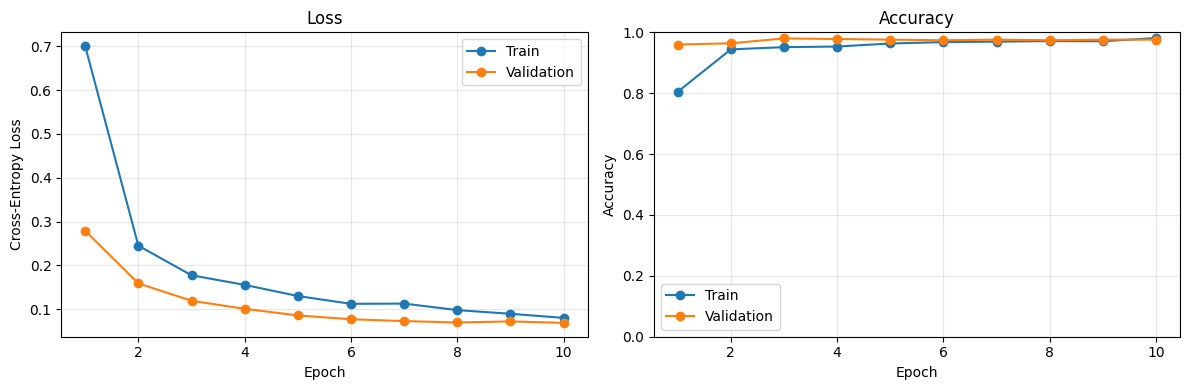

In [45]:
import matplotlib.pyplot as plt

epochs = range(1, num_epochs + 1)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4),
)

# Loss曲线
axes[0].plot(
    epochs,
    history["train_loss"],
    marker="o",
    label="Train",
)

axes[0].plot(
    epochs,
    history["val_loss"],
    marker="o",
    label="Validation",
)

axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy曲线
axes[1].plot(
    epochs,
    history["train_accuracy"],
    marker="o",
    label="Train",
)

axes[1].plot(
    epochs,
    history["val_accuracy"],
    marker="o",
    label="Validation",
)

axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()